# Train / Val / Test Split

**Input**: `data/processed/merged_inspections_licenses_inner_clean.parquet`  
**Output**:
- `data/processed/train.parquet` / `train.csv`
- `data/processed/val.parquet` / `val.csv`
- `data/processed/test.parquet` / `test.csv`

## Strategy: Temporal 3-way Split

Food inspections are **time-series events** — a model trained on this data will be used to
predict *future* inspection outcomes. A random split would leak future information.
We split on `Inspection Date` into three non-overlapping windows:

- **Train**: earliest inspections (~64% of all rows)  
- **Val**: middle window, carved from the tail of train (~16%) — used for hyperparameter tuning  
- **Test**: most recent inspections (~20%) — touched only for final evaluation

The cutoffs are chosen so that test ≈ 20% of total, and val ≈ 20% of the remaining train.

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from helpers.data_loader import DataLoader

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

# ── Paths ──────────────────────────────────────────────────────────
INPUT_PATH   = DataLoader.processed('merged_inspections_licenses_inner_clean.parquet')
TRAIN_CSV    = DataLoader.processed('train.csv')
TRAIN_PARQ   = DataLoader.processed('train.parquet')
VAL_CSV      = DataLoader.processed('val.csv')
VAL_PARQ     = DataLoader.processed('val.parquet')
TEST_CSV     = DataLoader.processed('test.csv')
TEST_PARQ    = DataLoader.processed('test.parquet')

# ── Config ─────────────────────────────────────────────────────────
TARGET_COL      = 'Results'
DATE_COL        = 'Inspection Date'
ID_COL          = 'Inspection ID'
TEST_FRACTION   = 0.20          # target fraction for the test set
VAL_FRACTION    = 0.20          # target fraction for val (of remaining train, ~16% of total)
RANDOM_STATE    = 42

## 1 · Load cleaned data

In [2]:
df = pd.read_parquet(INPUT_PATH)
print('Loaded shape:', df.shape)
print('Columns:', list(df.columns))
df.head(3)

Loaded shape: (171470, 26)
Columns: ['Inspection ID', 'DBA Name', 'AKA Name', 'License #', 'Facility Type', 'Risk', 'Address', 'Zip', 'Inspection Date', 'Inspection Type', 'Results', 'Violations', 'Latitude', 'Longitude', 'COMMUNITY AREA NAME', 'LICENSE DESCRIPTION', 'APPLICATION TYPE', 'LICENSE TERM START DATE', 'LICENSE TERM EXPIRATION DATE', 'LICENSE STATUS', 'flag_non_il_state', 'flag_non_chicago_city', 'flag_longitude_outside_typical_range', 'violations_recorded', 'license_matched', 'has_prior_inspection']


,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,Zip,Inspection Date,Inspection Type,Results,Violations,Latitude,Longitude,COMMUNITY AREA NAME,LICENSE DESCRIPTION,APPLICATION TYPE,LICENSE TERM START DATE,LICENSE TERM EXPIRATION DATE,LICENSE STATUS,flag_non_il_state,flag_non_chicago_city,flag_longitude_outside_typical_range,violations_recorded,license_matched,has_prior_inspection
0,44247,EAT A PITA,EAT A PITA,1222441.0,Restaurant,High,3155 N HALSTED ST,60657.0,2010-01-05,Complaint,Pass,"30. FOOD IN ORIGINAL CONTAINER, PROPERLY LABEL...",41.939441,-87.649103,LAKE VIEW,Retail Food Establishment,RENEW,NaN,2019-02-15,AAI,False,False,False,True,False,False
1,44248,LA GONDOLA,LA GONDOLA,1336561.0,Restaurant,High,2914 N ASHLAND AVE,60657.0,2010-01-21,Canvass,Pass,32. FOOD AND NON-FOOD CONTACT SURFACES PROPERL...,41.934679,-87.668625,LAKE VIEW,Retail Food Establishment,RENEW,NaN,2025-02-15,AAI,False,False,False,True,False,True
2,44249,AZHA RESTAURANT INC.,AZHA RESTAURANT,1334073.0,Restaurant,High,960 W BELMONT AVE,60657.0,2010-01-21,Canvass Re-Inspection,Pass,"35. WALLS, CEILINGS, ATTACHED EQUIPMENT CONSTR...",41.940027,-87.653811,LAKE VIEW,Retail Food Establishment,RENEW,NaN,2013-02-15,AAC,False,False,False,True,False,True


## 2 · Parse & validate Inspection Date

In [3]:
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

null_dates = df[DATE_COL].isna().sum()
print(f'Null dates: {null_dates}  ({null_dates / len(df) * 100:.2f}%)')

if null_dates > 0:
    print('Dropping rows with null Inspection Date (cannot place in time).')
    df = df.dropna(subset=[DATE_COL]).copy()
    print(f'Shape after dropping null dates: {df.shape}')

print(f'Date range: {df[DATE_COL].min().date()}  →  {df[DATE_COL].max().date()}')

Null dates: 0  (0.00%)
Date range: 2010-01-04  →  2019-12-04


## 3 · Compute temporal cutoff

In [4]:
# Sort by date to find the cutoff that gives ~80/20 split
df = df.sort_values(DATE_COL).reset_index(drop=True)

cutoff_idx  = int(len(df) * (1 - TEST_FRACTION))
cutoff_date = df.loc[cutoff_idx, DATE_COL]

print(f'Cutoff index : {cutoff_idx:,}')
print(f'Cutoff date  : {cutoff_date.date()}')
print(f'Rows before  : {cutoff_idx:,}  ({cutoff_idx / len(df) * 100:.1f}%)')
print(f'Rows on/after: {len(df) - cutoff_idx:,}  ({(len(df) - cutoff_idx) / len(df) * 100:.1f}%)')

Cutoff index : 137,176
Cutoff date  : 2017-08-31
Rows before  : 137,176  (80.0%)
Rows on/after: 34,294  (20.0%)


## 4 · Split

In [5]:
train_mask = df[DATE_COL] < cutoff_date
test_mask  = ~train_mask

df_train = df.loc[train_mask].copy()
df_test  = df.loc[test_mask].copy()

print(f'Train : {len(df_train):>7,} rows  ({len(df_train)/len(df)*100:.1f}%)')
print(f'Test  : {len(df_test):>7,} rows  ({len(df_test)/len(df)*100:.1f}%)')
print(f'Total : {len(df):>7,} rows')

# Sanity: no overlap
assert df_train[DATE_COL].max() < df_test[DATE_COL].min(), \
    'Data leakage detected — train dates overlap with test dates!'
print(f'\n No temporal overlap  (train max: {df_train[DATE_COL].max().date()}, '
      f'test min: {df_test[DATE_COL].min().date()})')

Train : 137,176 rows  (80.0%)
Test  :  34,294 rows  (20.0%)
Total : 171,470 rows

 No temporal overlap  (train max: 2017-08-30, test min: 2017-08-31)


## 5 · Carve validation from train

In [6]:
# Further split df_train into train / val by date (val = last VAL_FRACTION of train)
df_train = df_train.reset_index(drop=True)
val_cutoff_idx  = int(len(df_train) * (1 - VAL_FRACTION))
val_cutoff_date = df_train.loc[val_cutoff_idx, DATE_COL]

print(f'Val cutoff index : {val_cutoff_idx:,}')
print(f'Val cutoff date  : {val_cutoff_date.date()}')

val_mask = df_train[DATE_COL] >= val_cutoff_date
df_val   = df_train.loc[val_mask].copy()
df_train = df_train.loc[~val_mask].copy()

print(f'Train : {len(df_train):>7,} rows  ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val   : {len(df_val):>7,} rows  ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test  : {len(df_test):>7,} rows  ({len(df_test)/len(df)*100:.1f}%)')

# Sanity: no temporal overlap
assert df_train[DATE_COL].max() < df_val[DATE_COL].min(), \
    'Data leakage: train/val dates overlap!'
assert df_val[DATE_COL].max() < df_test[DATE_COL].min(), \
    'Data leakage: val/test dates overlap!'
print(f'\n No temporal overlap  '
      f'(train_max: {df_train[DATE_COL].max().date()}, '
      f'val_min: {df_val[DATE_COL].min().date()}, '
      f'val_max: {df_val[DATE_COL].max().date()}, '
      f'test_min: {df_test[DATE_COL].min().date()})')

Val cutoff index : 109,740
Val cutoff date  : 2016-04-11
Train : 109,693 rows  (64.0%)
Val   :  27,483 rows  (16.0%)
Test  :  34,294 rows  (20.0%)

 No temporal overlap  (train_max: 2016-04-08, val_min: 2016-04-11, val_max: 2017-08-30, test_min: 2017-08-31)


## 6 · Validate target distribution

In [7]:
def target_distribution(df_subset: pd.DataFrame, label: str) -> pd.DataFrame:
    """Return value-counts with percentages for the target column."""
    counts = df_subset[TARGET_COL].value_counts()
    pcts   = df_subset[TARGET_COL].value_counts(normalize=True).mul(100).round(2)
    out = pd.DataFrame({'count': counts, 'pct': pcts})
    out.columns = pd.MultiIndex.from_product([[label], out.columns])
    return out

dist = pd.concat([
    target_distribution(df_train, 'Train'),
    target_distribution(df_val,   'Val'),
    target_distribution(df_test,  'Test'),
    target_distribution(df,       'Overall'),
], axis=1)

print('Target distribution across splits:\n')
dist

Target distribution across splits:



Train           Val          Test        Overall       
                    count    pct  count    pct  count    pct   count    pct
Results                                                                    
Pass                73966  67.43  18024  65.58  14013  40.86  106003  61.82
Fail                24269  22.12   6051  22.02   7735  22.55   38055  22.19
Pass w/ Conditions  11458  10.45   3408   12.4  12546  36.58   27412  15.99

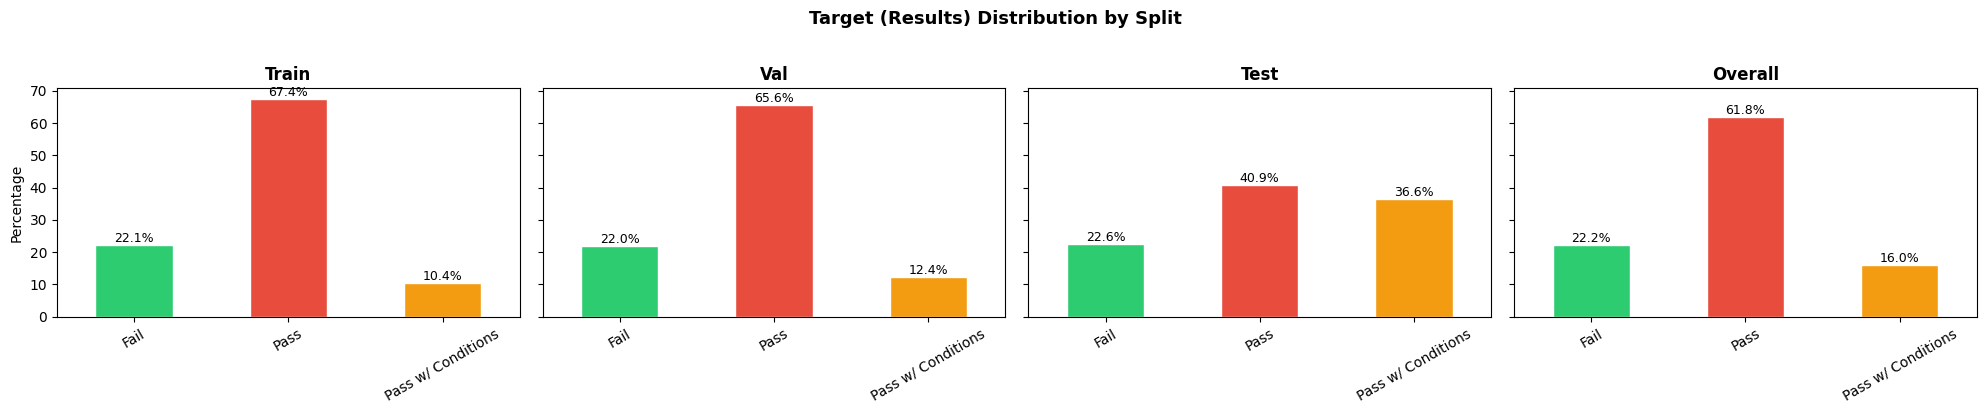

In [8]:
# Visual comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

for ax, (subset, title) in zip(axes, [
    (df_train, 'Train'),
    (df_val,   'Val'),
    (df_test,  'Test'),
    (df,       'Overall'),
]):
    pcts = subset[TARGET_COL].value_counts(normalize=True).mul(100)
    pcts.sort_index().plot.bar(ax=ax, color=['#2ecc71', '#e74c3c', '#f39c12'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Percentage' if ax == axes[0] else '')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.1f}%',
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)

fig.suptitle('Target (Results) Distribution by Split', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7 · Leakage checks

In [9]:
# Check 1: No shared Inspection IDs across any pair of splits
shared_tv  = set(df_train[ID_COL]) & set(df_val[ID_COL])
shared_tt  = set(df_train[ID_COL]) & set(df_test[ID_COL])
shared_vt  = set(df_val[ID_COL])   & set(df_test[ID_COL])
print(f'Shared Train/Val  IDs : {len(shared_tv)}')
print(f'Shared Train/Test IDs : {len(shared_tt)}')
print(f'Shared Val/Test   IDs : {len(shared_vt)}')
assert not shared_tv,  f'Leakage: {len(shared_tv)} IDs in train & val!'
assert not shared_tt,  f'Leakage: {len(shared_tt)} IDs in train & test!'
assert not shared_vt,  f'Leakage: {len(shared_vt)} IDs in val & test!'

# Check 2: Train + Val + Test = Original (no rows lost or duplicated)
assert len(df_train) + len(df_val) + len(df_test) == len(df), \
    f'Row mismatch: {len(df_train)} + {len(df_val)} + {len(df_test)} ≠ {len(df)}'

# Check 3: Date boundary integrity
print(f'Train date range : {df_train[DATE_COL].min().date()}  ->  {df_train[DATE_COL].max().date()}')
print(f'Val   date range : {df_val[DATE_COL].min().date()}  ->  {df_val[DATE_COL].max().date()}')
print(f'Test  date range : {df_test[DATE_COL].min().date()}  ->  {df_test[DATE_COL].max().date()}')

print('\nAll leakage checks passed.')

Shared Train/Val  IDs : 0
Shared Train/Test IDs : 0
Shared Val/Test   IDs : 0
Train date range : 2010-01-04  ->  2016-04-08
Val   date range : 2016-04-11  ->  2017-08-30
Test  date range : 2017-08-31  ->  2019-12-04

All leakage checks passed.


## 8 · Export

In [10]:
TRAIN_CSV.parent.mkdir(parents=True, exist_ok=True)

df_train.to_csv(TRAIN_CSV, index=False)
df_train.to_parquet(TRAIN_PARQ, index=False)

df_val.to_csv(VAL_CSV, index=False)
df_val.to_parquet(VAL_PARQ, index=False)

df_test.to_csv(TEST_CSV, index=False)
df_test.to_parquet(TEST_PARQ, index=False)

print(f'Saved train -> {TRAIN_CSV}  ({TRAIN_CSV.stat().st_size / 1e6:.1f} MB csv)')
print(f'               {TRAIN_PARQ}  ({TRAIN_PARQ.stat().st_size / 1e6:.1f} MB parquet)')
print(f'Saved val   -> {VAL_CSV}  ({VAL_CSV.stat().st_size / 1e6:.1f} MB csv)')
print(f'               {VAL_PARQ}  ({VAL_PARQ.stat().st_size / 1e6:.1f} MB parquet)')
print(f'Saved test  -> {TEST_CSV}  ({TEST_CSV.stat().st_size / 1e6:.1f} MB csv)')
print(f'               {TEST_PARQ}  ({TEST_PARQ.stat().st_size / 1e6:.1f} MB parquet)')

Saved train -> ..\..\data\processed\train.csv  (138.7 MB csv)
               ..\..\data\processed\train.parquet  (38.1 MB parquet)
Saved val   -> ..\..\data\processed\val.csv  (33.4 MB csv)
               ..\..\data\processed\val.parquet  (10.2 MB parquet)
Saved test  -> ..\..\data\processed\test.csv  (50.8 MB csv)
               ..\..\data\processed\test.parquet  (15.5 MB parquet)


## 9 · Summary

In [11]:
summary = pd.DataFrame({
    'Split':      ['Train', 'Val', 'Test', 'Total'],
    'Rows':       [len(df_train), len(df_val), len(df_test), len(df)],
    'Pct':        [f'{len(df_train)/len(df)*100:.1f}%', f'{len(df_val)/len(df)*100:.1f}%',
                   f'{len(df_test)/len(df)*100:.1f}%', '100.0%'],
    'Date Start': [df_train[DATE_COL].min().date(), df_val[DATE_COL].min().date(),
                   df_test[DATE_COL].min().date(),   df[DATE_COL].min().date()],
    'Date End':   [df_train[DATE_COL].max().date(), df_val[DATE_COL].max().date(),
                   df_test[DATE_COL].max().date(),   df[DATE_COL].max().date()],
    'Columns':    [df_train.shape[1], df_val.shape[1], df_test.shape[1], df.shape[1]],
})

print('═' * 70)
print('  SPLIT SUMMARY')
print('═' * 70)
summary

══════════════════════════════════════════════════════════════════════
  SPLIT SUMMARY
══════════════════════════════════════════════════════════════════════


,Split,Rows,Pct,Date Start,Date End,Columns
0,Train,109693,64.0%,2010-01-04,2016-04-08,26
1,Val,27483,16.0%,2016-04-11,2017-08-30,26
2,Test,34294,20.0%,2017-08-31,2019-12-04,26
3,Total,171470,100.0%,2010-01-04,2019-12-04,26
